In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df_raw = pd.read_csv("el_nino.csv")
df_cleaned = df_raw.dropna()
df_cleaned["date"] = pd.to_datetime(df_cleaned["date"].astype(str), format="%y%m%d")

df_cleaned["hemisphere"] = "west"
df_cleaned.loc[df_cleaned["longitude"] <= -50, "hemisphere"] = "east"
df_cleaned


,year,month,day,date,latitude,longitude,zon_winds,mer_winds,humidity,air_temp,ss_temp,hemisphere
4059,93,5,9,1993-05-09,-0.02,-109.96,-2.1,2.1,81.2,26.80,27.02,east
4060,93,5,10,1993-05-10,-0.02,-109.96,-3.4,1.4,84.2,26.95,26.91,east
4061,93,5,11,1993-05-11,-0.02,-109.96,-3.8,2.2,84.9,26.98,26.78,east
4062,93,5,12,1993-05-12,-0.02,-109.96,-3.0,1.5,86.9,26.93,26.74,east
4063,93,5,13,1993-05-13,-0.02,-109.96,-4.5,1.9,87.6,27.01,26.82,east
...,...,...,...,...,...,...,...,...,...,...,...,...
178074,98,6,10,1998-06-10,8.95,-140.33,-6.8,-5.3,81.3,27.52,28.17,east
178075,98,6,11,1998-06-11,8.96,-140.33,-5.1,-0.4,94.1,26.04,28.14,east
178076,98,6,12,1998-06-12,8.96,-140.32,-4.3,-3.3,93.2,25.80,27.87,east
178077,98,6,13,1998-06-13,8.95,-140.34,-6.1,-4.8,81.3,27.17,27.93,east


In [ ]:
west_hem = df_cleaned[(df_cleaned["longitude"] <= -50 )]
west_hem.drop(["longitude", "latitude"], axis=1, inplace=True)

west_hem_grouped = west_hem.groupby(["year", "month", "day", "date"]).mean()

west_hem_grouped.reset_index(inplace=True)

In [ ]:
east_hem = df_cleaned[(df_cleaned["longitude"] > -50 )]
east_hem.drop(["longitude", "latitude"], axis=1, inplace=True)

east_hem_grouped = east_hem.groupby(["year", "month", "day", "date"]).mean()

east_hem_grouped.reset_index(inplace=True)

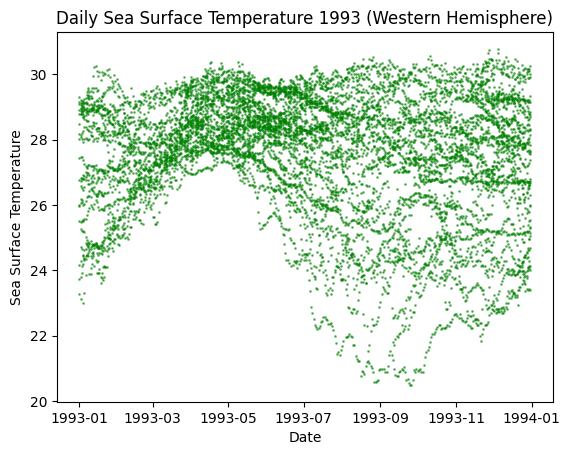

In [12]:
west_hem_93 = west_hem[(west_hem["year"] == 93)]
west_hem_93["date"] = pd.to_datetime(west_hem_93["date"].astype(str), format="%y%m%d")

plt.scatter(west_hem_93["date"], west_hem_93["ss_temp"], marker="o",alpha=0.5, s=1, color="green")
plt.xlabel("Date")
plt.ylabel("Sea Surface Temperature")
plt.title("Daily Sea Surface Temperature 1993 (Western Hemisphere)")

plt.show()

In [23]:
df_cleaned = df_cleaned.sort_values(by='date')
df_cleaned

,year,month,day,date,latitude,longitude,zon_winds,mer_winds,humidity,air_temp,ss_temp,hemisphere
75636,89,11,29,1989-11-29,-2.04,-140.09,-7.2,-0.2,78.7,26.01,25.92,east
75637,89,11,30,1989-11-30,-2.03,-140.08,-6.1,0.2,76.9,25.82,25.98,east
75638,89,12,1,1989-12-01,-2.05,-140.08,-5.2,0.0,75.9,25.58,26.03,east
75639,89,12,2,1989-12-02,-2.04,-140.07,-3.7,-0.4,76.8,25.46,26.14,east
75640,89,12,3,1989-12-03,-2.04,-140.08,-4.6,-0.6,75.7,25.54,26.16,east
...,...,...,...,...,...,...,...,...,...,...,...,...
157095,98,6,22,1998-06-22,8.00,-170.07,-6.4,-4.0,90.2,27.54,28.33,east
151886,98,6,22,1998-06-22,8.08,156.02,-5.6,-3.1,86.5,28.41,28.96,west
171397,98,6,22,1998-06-22,-7.98,-170.03,-4.2,-3.5,81.1,28.41,29.19,east
136959,98,6,22,1998-06-22,-4.99,165.21,-3.5,-1.2,78.5,28.16,29.38,west


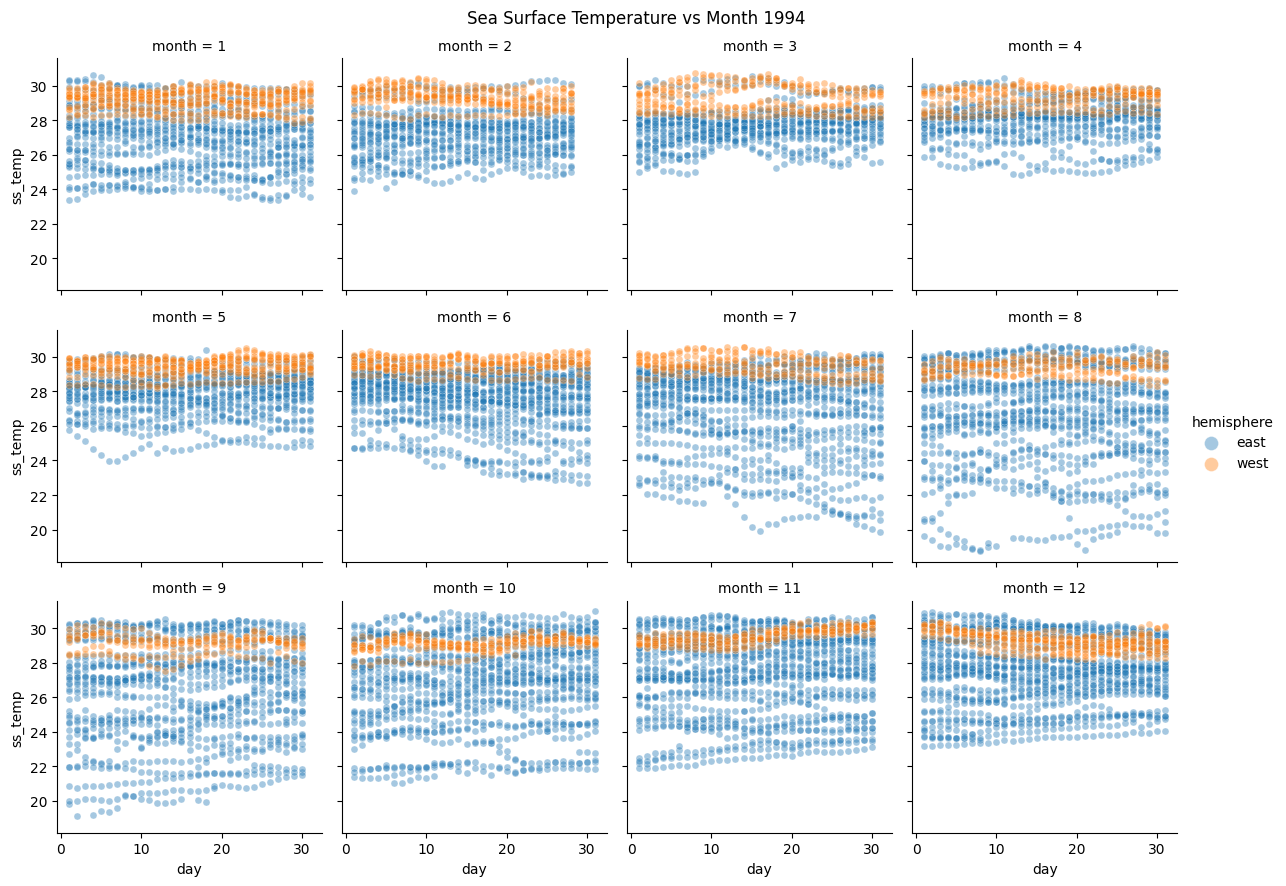

In [29]:
year = 94

g = sns.FacetGrid(df_cleaned[(df_cleaned["year"] == year)], col="month", col_wrap=4, hue="hemisphere")
g.figure.suptitle(f"Sea Surface Temperature vs Month 19{year}")

g.map(sns.scatterplot, "day", "ss_temp", alpha=0.4, s=25)
g.add_legend(markerscale=2)